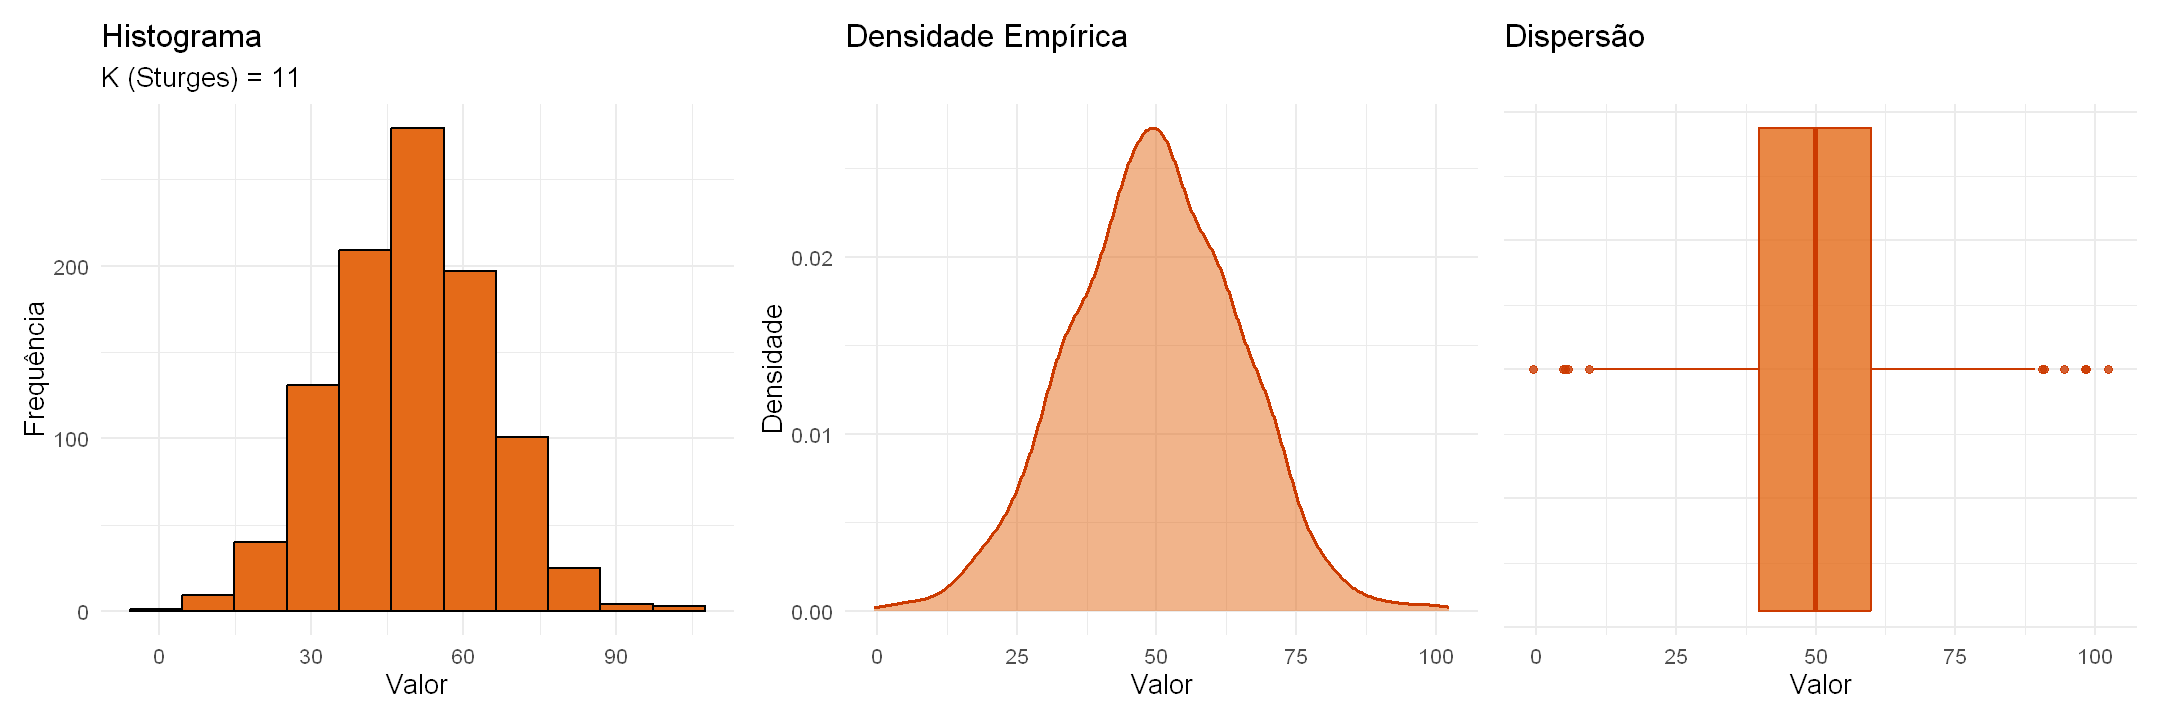

In [1]:
# 1. Trava o tamanho do gráfico para a célula do Jupyter Notebook (Largura x Altura em polegadas)
options(repr.plot.width = 18, repr.plot.height = 6)

# 2. Pacotes
library(ggplot2)
library(patchwork)

# 3. Dados Simulados e Variáveis
set.seed(42)
dados_exemplo <- data.frame(valor_estado = rnorm(1000, mean = 50, sd = 15))

k_sturges <- nclass.Sturges(dados_exemplo$valor_estado)
cor_fundo <- "#e46a18"  # Laranja
cor_borda <- "#cc3a00"  # Laranja Escuro
fonte_base <- 16        # Tamanho da fonte legível

# 4. Gráficos Individuais
# A. Histograma
p_hist <- ggplot(dados_exemplo, aes(x = valor_estado)) +
  geom_histogram(bins = k_sturges, fill = cor_fundo, color = "black") +
  labs(title = "Histograma", subtitle = paste("K (Sturges) =", k_sturges), x = "Valor", y = "Frequência") +
  theme_minimal(base_size = fonte_base)

# B. Curva KDE
p_kde <- ggplot(dados_exemplo, aes(x = valor_estado)) +
  geom_density(fill = cor_fundo, alpha = 0.5, color = cor_borda, linewidth = 1) +
  labs(title = "Densidade Empírica", x = "Valor", y = "Densidade") +
  theme_minimal(base_size = fonte_base)

# C. Boxplot (Eixo X para acompanhar a leitura dos outros gráficos)
p_box <- ggplot(dados_exemplo, aes(x = valor_estado)) +
  geom_boxplot(fill = cor_fundo, color = cor_borda, alpha = 0.8) +
  labs(title = "Dispersão", x = "Valor") +
  theme_minimal(base_size = fonte_base) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())

# 5. Montagem Final (Lado a lado, dividindo o espaço igualmente)
painel <- p_hist + p_kde + p_box + plot_layout(ncol = 3, widths = c(1, 1, 1))

# Renderiza
painel